In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']
test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
label_names=emotion_dataset['train'].features['label'].names

In [ ]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train=pd.DataFrame({
    'text':train_text,
    'label':[label_names[i] for i in train_label]
})
df_test=pd.DataFrame({
    'text':test_text,
    'label':[label_names[i] for i in test_label]
})

In [ ]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [ ]:
df_train.isnull().sum()

,0
text,0
label,0


In [ ]:
df_test.isnull().sum()

,0
text,0
label,0


In [ ]:
#EDA

<Axes: xlabel='label', ylabel='count'>

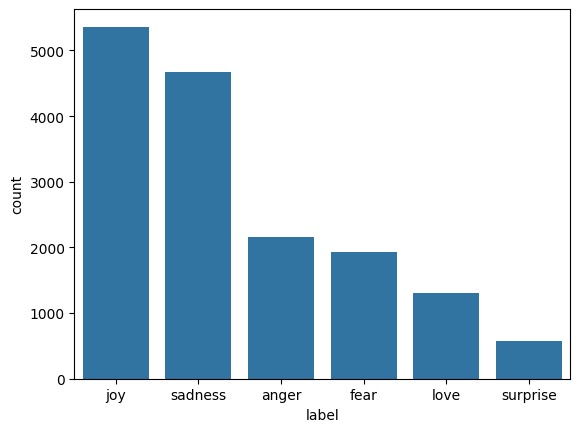

In [ ]:
sns.countplot(x='label',data=df_train, order=df_train['label'].value_counts().index)

In [ ]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [ ]:
#Data preprocessing-Using NLP

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words=10000

tokenizer=Tokenizer(num_words=max_words,oov_token='<unk>')#out of word is unknown
tokenizer.fit_on_texts(df_train['text'])
train_sequences=tokenizer.texts_to_sequences(df_train['text'])#convert into numbers
test_sequences=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequences=pad_sequences(train_sequences,maxlen=100,padding='post',truncating='post')#added pading fore extra sequence
padded_test_sequences=pad_sequences(test_sequences,maxlen=100,padding='post',truncating='post')

In [ ]:
#Converting for labels
train_labels=np.array(train_label)
test_labels=np.array(test_label)

num_classes=len(np.unique(train_labels))
num_classes

print(f"vocubulary size:{len(tokenizer.word_index)+1}")
print(f"max sentence length:{padded_train_sequences.shape[1]}")

vocubulary size:15214
max sentence length:100


In [ ]:
#calculating the classes
from sklearn.utils import class_weight

class_weights=class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict=dict(enumerate(class_weights))

In [ ]:
#early stoping for training

from tensorflow.keras.callbacks import EarlyStopping

early_stopping=EarlyStopping(
    monitor='val_loss',#validation loss
    patience=3,
    restore_best_weights=True
)

In [ ]:
#Traning the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout,SimpleRNN,GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])



In [ ]:
#Simple RNN
rnn_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - accuracy: 0.1459 - loss: 1.8021 - val_accuracy: 0.2580 - val_loss: 1.7800
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.1478 - loss: 1.8006 - val_accuracy: 0.0475 - val_loss: 1.8075
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.1447 - loss: 1.7996 - val_accuracy: 0.0820 - val_loss: 1.7944
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2580 - loss: 1.7800
RNN Loss: 1.7799769639968872
RNN Accuracy: 0.257999986410141


In [ ]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2580 - loss: 1.7800
RNN Loss: 1.7799769639968872
RNN Accuracy: 0.257999986410141


In [ ]:
#Standard LSTM

lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 127s 246ms/step - accuracy: 0.1559 - loss: 1.7954 - val_accuracy: 0.1120 - val_loss: 1.7915
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 246ms/step - accuracy: 0.1565 - loss: 1.7942 - val_accuracy: 0.1120 - val_loss: 1.7866
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 244ms/step - accuracy: 0.1539 - loss: 1.7935 - val_accuracy: 0.1120 - val_loss: 1.7823
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.1120 - loss: 1.7915
LSTM Loss: 1.791512131690979
LSTM Accuracy: 0.1120000034570694


In [ ]:
#Standard GRU
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 110s 214ms/step - accuracy: 0.1510 - loss: 1.7971 - val_accuracy: 0.3475 - val_loss: 1.7625
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 208ms/step - accuracy: 0.1746 - loss: 1.7951 - val_accuracy: 0.3475 - val_loss: 1.7902
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 104s 208ms/step - accuracy: 0.1497 - loss: 1.7955 - val_accuracy: 0.0795 - val_loss: 1.7962
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.3475 - loss: 1.7625
GRU Loss: 1.7625409364700317
GRU Accuracy: 0.3474999964237213


In [36]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
2,GRU,1.762541,0.3475
0,RNN,1.779977,0.2580
1,LSTM,1.791512,0.1120


In [37]:
#ADvance Bidirectional GRU
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer

])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
BiGRU.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 316s 613ms/step - accuracy: 0.5921 - loss: 1.0783 - val_accuracy: 0.8920 - val_loss: 0.3159
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 303s 606ms/step - accuracy: 0.9249 - loss: 0.2133 - val_accuracy: 0.9210 - val_loss: 0.2007
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 302s 604ms/step - accuracy: 0.9518 - loss: 0.1319 - val_accuracy: 0.9225 - val_loss: 0.2300
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 317s 596ms/step - accuracy: 0.9628 - loss: 0.1046 - val_accuracy: 0.9200 - val_loss: 0.2450
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 297s 593ms/step - accuracy: 0.9701 - loss: 0.0863 - val_accuracy: 0.9275 - val_loss: 0.2458


In [39]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequences, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.9210 - loss: 0.2007
BiGRU Loss: 0.2007025182247162
BiGRU Accuracy: 0.9210000038146973


63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 182ms/step


<Axes: >

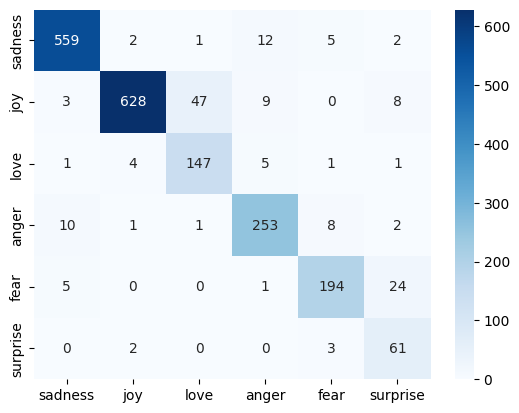

In [41]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequences),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)



In [42]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [43]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)